# SentimentScope: Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, you will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset. You are a Machine Learning Engineer at Cinescope, a growing entertainment company working to enhance its recommendation system. Your task is to fine-tune a transformer-based model for sentiment analysis using the IMDB dataset. By classifying reviews as positive or negative, you will help the company better understand user sentiment and deliver more personalized experiences.

By completing this project, you will demonstrate your competency in the following learning objectives:

- Load, explore, and prepare a text dataset for training a transformer model using PyTorch.
- Customize the architecture of the transformer model for a classification task.
- Train and test a transformer model on the IMDB dataset.

Now that you have an overview of what you will achieve in this project, let’s move on to the project outline.

---

### Project Outline

This notebook is organized into the following sections:


1. [Introduction](#introduction): Overview of the project, learning objectives, and understanding sentiment analysis.
2. [Load, Explore, and Prepare the Dataset](#load-explore-and-prepare-the-dataset): Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. [Implement a DataLoader in PyTorch](#implement-a-dataloader-in-pytorch): Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. [Customize the Transformer Architecture](#customize-the-transformer-architecture): Modify the transformer model for binary classification.
5. [Implement Accuracy Calculation Method](#implement-accuracy-calculation-method): Create a function to compute accuracy for monitoring performance.
6. [Train the Model](#train-the-model): Complete and execute the training loop for binary classification.
7. [Test the Model](#test-the-model): Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. [Conclusion](#conclusion): Summarize the project results and key takeaways.

Click on the section titles above to navigate directly to the corresponding part of the notebook!

---

Now that we've outlined the structure and objectives of this project, let's delve into the core concept: sentiment analysis.

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, you will classify IMDB movie reviews as positive or negative to tackle the challenge faced by your entertainment company CineScope by enhancing its recommendation system, enabling more accurate and personalized suggestions.

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

For example, consider the following movie review:

> "The movie was a rollercoaster of emotions, and I loved every moment of it!"

This review is clearly positive as it expresses enjoyment and satisfaction with the movie, hence it will be labelled as *positive* or 1 in the dataset. In contrast:

> "The plot was predictable, and the acting was subpar. A waste of time."

This review conveys a negative sentiment, criticizing both the plot and acting, hence it will be labelled as *negative* or 0 in the dataset.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture. You might already be familiar with the tweaks that we will implement in this project.


---

### Data Description

The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/), provided in the `aclIMDB_v1.tar.gz` file. Upon extracting the file, you will find the following folder structure:

```
aclIMDB/
├── train/
│   ├── pos/    # Positive reviews for training
│   ├── neg/    # Negative reviews for training
│   ├── unsup/  # Unsupervised data (not used in this project)
├── test/
│   ├── pos/    # Positive reviews for testing
│   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

---


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset
The dataset is already available in the environment as `aclIMDB_v1.tar.gz`. We will load it into Pandas DataFrames for easy exploration and preparation.


In [1]:
!pip install seaborn

In [2]:
import os
import pandas as pd

In [3]:
!tar -xzf aclImdb_v1.tar.gz

In [4]:
train_pos_path = 'aclImdb/train/pos' # Path to the directory containing positive reviews from the training set
train_neg_path = 'aclImdb/train/neg' # Path to the directory containing negative reviews from the training set
test_pos_path = 'aclImdb/test/pos' # Path to the directory containing positive reviews from the test set
test_neg_path = 'aclImdb/test/neg' # Path to the directory containing negative reviews from the test set

In [6]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.

    Args:
        folder (str): Path to the folder containing text files.

    Returns:
        list: A list of strings, where each string is the content of a text file.
    """
    #Implement the function here
    data = []
    for filename in os.listdir(folder):

        filepath = os.path.join(folder, filename)


        if os.path.isfile(filepath):

            with open(filepath, 'r', encoding='utf-8') as file:
                data.append(file.read())

    return data

In [7]:
# Loading training and testing data
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

In [8]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  After Fatih Akins first work "Im Juli", which ...      1
1  When I saw this film in the 1950s, I wanted to...      1
2  After hitting the viewers with three very diff...      1
3  God! Zorro has been the the subject of about a...      1
4  Okay, I know I shouldn't like this movie but I...      1


In [9]:
import matplotlib.pyplot as plt

In [10]:
print("=== Dataset Info ===")
train_df.info()
print("\n")

print("=== Label Distribution ===")
print(train_df['label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


=== Label Distribution ===
label
1    12500
0    12500
Name: count, dtype: int64


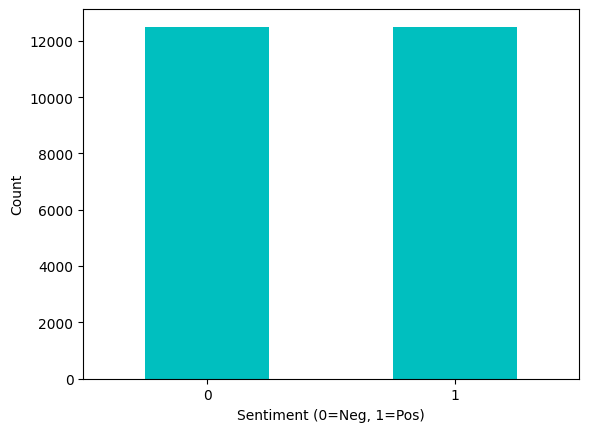

In [11]:
train_df['label'].value_counts().sort_index().plot(kind='bar', color="c")
plt.xlabel("Sentiment (0=Neg, 1=Pos)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()



=== Review Length Statistics ===
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length, dtype: float64




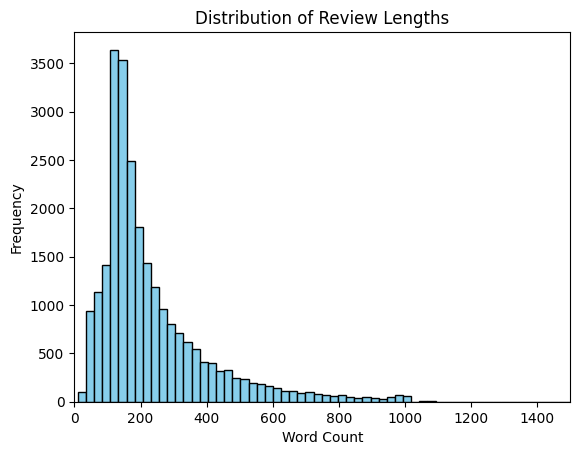

In [12]:
train_df['review_length'] = train_df['review'].apply(lambda x: len(x.split()))

print("=== Review Length Statistics ===")
print(train_df['review_length'].describe())
print("\n")
plt.hist(train_df['review_length'], bins=100, color='skyblue', edgecolor='black')

plt.title('Distribution of Review Lengths')
plt.xlim(0, 1500)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [13]:
print("=== Sample Positive Review ===")
# iloc[0] will get the first positive review from our loaded data
print(train_df[train_df['label'] == 1]['review'].iloc[0])
print("\n")

print("=== Sample Negative Review ===")
# iloc[0] will get the first negative review
print(train_df[train_df['label'] == 0]['review'].iloc[0])

=== Sample Positive Review ===
After Fatih Akins first work "Im Juli", which was fairly good, he created a really gorgeous italian family epic. Its a german movie, which is unfortunately a bad precondition, cause we rareley produce more than moderate movies ;). But this movie makes some very good snapshots of the time then. "Solino" is about a Italian immigrant who arrives in the "Ruhr" region of Germany during the 60s. The immigrant and his family then start the first Pizza restaurant in the region. The characters are excellent drawn. Especially Gigi, the main actor. You live every second, every feeling he does. His brother, played by Moritz Bleibtreu, isnt that good. Well, you just dont believe him the role. But the character is wellbalanced and fits perfectly into this script. I feel an urgent need to compare the style of this movie with the style of "The Godfather". Many people will probably hate this movie, say its boring. Not much tension? - yes, but an outrageous movie. 9 out of

### 3. Prepare the Dataset




In [14]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))
# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

### 4. Testing the Tokenizer

`AutoTokenizer`, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the `bert-base-uncased` tokenizer, which applies **subword tokenization**. Subword tokenization involves two steps:

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

In [17]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  1045,  5959,  2035,  1996,  4617,  1997,  2023,  2466,  2021,
          2023,  2028,  2003,  2026,  2035,  2051,  5440,  1012,  2577,  1039,
          1012,  3660,  3957,  1037,  5995,  2000,  1996,  8040,  3217, 23884,
          2839,  2008,  1996,  2500,  2079,  2025,  2507,  1012,  1996,  3185,
          3065,  2062,  2055,  2339,  2002,  4150,  2061,  8618,  1012,  1996,
          3431,  1999,  8040,  3217, 23884,  3711,  6360,  2004,  2002, 11340,
          1996,  2367, 11277,  1998,  1996, 10444,  2008,  2027,  2265,  2032,
          1012,  1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,  2023,
          3185,  2038,  1996,  2190,  4714,  5199,  2011,  2521,  1012,  2002,
          2003,  1996,  2157,  2287,  2738,  2084,  2108,  2209,  2011,  2619,
          2040,  2003,  2471,  1037, 10563,  2004,  1999,  1996,  2060,  3152,
          1012,  4938, 19097,  2145,  2038,  2035,  2030,  2087,  1997,  2010,
          3336,  4091,  1012,  1026,  

# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>

In [18]:
import torch
from torch.utils.data import Dataset
MAX_LENGTH = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [19]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to 128.
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.reviews = data['review'].tolist()
        self.labels = data['label'].tolist()

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        return len(self.labels)


    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        review = self.reviews[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            review,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        input_ids = encoding['input_ids'].squeeze()


        return input_ids, label

### 2. Initialize the Dataset


In [20]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

### 3. Create a DataLoader


In [21]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture



In [22]:
config = {
    "vocabulary_size": tokenizer.vocab_size,
    "num_classes": 2,
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,
    "dropout_rate": 0.1,
    "use_bias": True
}


### 2. Class Definitions


In [24]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)
        K = self.K_weights(input)
        V = self.V_weights(input)


        attention_scores = Q @ K.transpose(1, 2)


        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

In [25]:
attention_head = AttentionHead(config).to(device)

dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 128, 32])


In [26]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)
        x = self.linear(x)
        x = self.dropout(x)
        return x

In [27]:
multi_head_attention = MultiHeadAttention(config).to(device)

dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 128, 128])


In [28]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [29]:
feed_forward = FeedForward(config).to(device)

dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 128, 128])


In [30]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [31]:
block = Block(config).to(device)

dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 128, 128])


In [32]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])

        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])

        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)

        self.layer_norm = nn.LayerNorm(config["d_embed"])

        self.classification_head = nn.Linear(config["d_embed"], config["num_classes"], bias=False)

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T),
                                    where B is the batch size, and T is the sequence length.

        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        x = self.token_embedding_layer(token_ids)
        positions = torch.arange(tokens_num, device=token_ids.device)
        pos_embed = self.positional_embedding_layer(positions)
        x = x + pos_embed.unsqueeze(0)

        x = self.layers(x)
        x = self.layer_norm(x)

        x_pooled = torch.mean(x, dim=1)
        logits = self.classification_head(x_pooled)

        return logits

In [34]:
demo_gpt = DemoGPT(config).to(device)

dummy_token_ids = torch.randint(
    0, config["vocabulary_size"],
    (BATCH_SIZE, config["context_size"])
).to(device)

logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[-0.0215, -0.0655],
        [-0.1377, -0.1176]], device='cuda:0', grad_fn=<SliceBackward0>)


## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>



In [35]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
        model (torch.nn.Module): The trained transformer model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
        float: Validation accuracy as a percentage.
    """
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)

            predictions = torch.argmax(logits, dim=1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [36]:
model = DemoGPT(config).to(device)

In [37]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 49.72%


## Train the Model <a name="train-the-model"></a>



In [44]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 10

model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for step, (input_ids, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        logits = model(input_ids)

        loss = criterion(logits, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if (step + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}")
            running_loss = 0.0

    val_accuracy = calculate_accuracy(model, val_loader, device)
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

Epoch [1/10], Step [100/704], Loss: 0.6938
Epoch [1/10], Step [200/704], Loss: 0.6728
Epoch [1/10], Step [300/704], Loss: 0.6502
Epoch [1/10], Step [400/704], Loss: 0.6319
Epoch [1/10], Step [500/704], Loss: 0.5976
Epoch [1/10], Step [600/704], Loss: 0.5871
Epoch [1/10], Step [700/704], Loss: 0.5691
Epoch 1 - Validation Accuracy: 72.24%
Epoch [2/10], Step [100/704], Loss: 0.5252
Epoch [2/10], Step [200/704], Loss: 0.5206
Epoch [2/10], Step [300/704], Loss: 0.5022
Epoch [2/10], Step [400/704], Loss: 0.5091
Epoch [2/10], Step [500/704], Loss: 0.4945
Epoch [2/10], Step [600/704], Loss: 0.5073
Epoch [2/10], Step [700/704], Loss: 0.4821
Epoch 2 - Validation Accuracy: 75.68%
Epoch [3/10], Step [100/704], Loss: 0.4397
Epoch [3/10], Step [200/704], Loss: 0.4444
Epoch [3/10], Step [300/704], Loss: 0.4270
Epoch [3/10], Step [400/704], Loss: 0.4328
Epoch [3/10], Step [500/704], Loss: 0.4302
Epoch [3/10], Step [600/704], Loss: 0.4213
Epoch [3/10], Step [700/704], Loss: 0.4310
Epoch 3 - Validation 

## Test the Model <a name="test-the-model"></a>


In [47]:
print("Calculating accuracy on the test set...")

test_accuracy = calculate_accuracy(model, test_loader, device)

print(f"Final Test Accuracy: {test_accuracy:.2f}%")


Calculating accuracy on the test set...
Final Test Accuracy: 76.73%


Summarize Project Results

This project successfully built a transformer-based model from scratch for binary sentiment analysis. The objective was to classify IMDB movie reviews as positive or negative to support CineScope's recommendation system.

The process involved:

- Data Loading : We loaded the text files from the `aclImdb` directory, organized them into Pandas DataFrames, and split the training data into a 90% training set (22,500 reviews) and a 10% validation set (2,500 reviews).
- Data Pipeline: We implemented a custom PyTorch `IMDBDataset` class. This class used the `bert-base-uncased` tokenizer to convert raw text into token IDs, applying padding and truncation to a `MAX_LENGTH` of 128.
- Model Architecture: We built the `DemoGPT` model from the ground up, including `AttentionHead`, `MultiHeadAttention`, and `Block` components. To adapt the model for classification, we implemented two key changes: mean pooling to create a single vector representation for each review and a final linear classification head to output two logits.


In [48]:
import torch

def predict_sentiment(review_text, model, tokenizer, device, max_length=128):

    model.eval()

    encoding = tokenizer(
        review_text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoding['input_ids'].to(device)

    with torch.no_grad():
        logits = model(input_ids)

        prediction = torch.argmax(logits, dim=1).item()

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment


In [49]:
import ipywidgets as widgets
from IPython.display import display

text_input = widgets.Textarea(
    value='',
    placeholder='Type a movie review here to test the model...',
    description='Review:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

button = widgets.Button(
    description="Analyze Sentiment",
    button_style='info',
    icon='check'
)

output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        review = text_input.value
        if review.strip() == "":
            print("Please enter a review first!")
            return

        print("Analyzing...")
        sentiment = predict_sentiment(review, model, tokenizer, device)
        output.clear_output()
        print(f"Review: {review}")
        print(f"Prediction: {sentiment}")

button.on_click(on_button_clicked)

display(text_input, button, output)

Textarea(value='', description='Review:', layout=Layout(height='100px', width='80%'), placeholder='Type a movi…

Button(button_style='info', description='Analyze Sentiment', icon='check', style=ButtonStyle())

Output()

In [50]:
import ipywidgets as widgets
from IPython.display import display

text_input = widgets.Textarea(
    value='',
    placeholder='Type a movie review here to test the model...',
    description='Review:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

button = widgets.Button(
    description="Analyze Sentiment",
    button_style='info',
    icon='check'
)

output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        review = text_input.value
        if review.strip() == "":
            print("Please enter a review first!")
            return

        print("Analyzing...")
        sentiment = predict_sentiment(review, model, tokenizer, device)
        output.clear_output()
        print(f"Review: {review}")
        print(f"Prediction: {sentiment}")

button.on_click(on_button_clicked)

display(text_input, button, output)

Textarea(value='', description='Review:', layout=Layout(height='100px', width='80%'), placeholder='Type a movi…

Button(button_style='info', description='Analyze Sentiment', icon='check', style=ButtonStyle())

Output()